### Data Cleaning and Processing

In [90]:
#Loading the required packages

import pandas as pd
import matplotlib as pyplot 
import seaborn as sn


In [92]:
#loading the data
Rental = pd.read_csv("/Users/nyadual/Desktop/Canada_Cost_of_Living/Rental_Prices_databaseLoadingData.csv")
Rental.head()

,REF_DATE,GEO,DGUID,Rental unit type,Estimates,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,Jan-20,"St. John's, Census metropolitan area (CMA)",2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,810.0,NaN,NaN,NaN,0
1,Apr-20,"St. John's, Census metropolitan area (CMA)",2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,860.0,NaN,NaN,NaN,0
2,Jul-20,"St. John's, Census metropolitan area (CMA)",2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,860.0,NaN,NaN,NaN,0
3,Oct-20,"St. John's, Census metropolitan area (CMA)",2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,850.0,NaN,NaN,NaN,0
4,Jan-21,"St. John's, Census metropolitan area (CMA)",2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,870.0,NaN,NaN,NaN,0


In [93]:
#cleaning the rental data
#remove CMA in the GEO column

Rental["GEO"] = Rental["GEO"].str.replace(",.*", "", regex=True).str.strip()
Rental.head()

,REF_DATE,GEO,DGUID,Rental unit type,Estimates,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,Jan-20,St. John's,2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,810.0,NaN,NaN,NaN,0
1,Apr-20,St. John's,2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,860.0,NaN,NaN,NaN,0
2,Jul-20,St. John's,2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,860.0,NaN,NaN,NaN,0
3,Oct-20,St. John's,2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,850.0,NaN,NaN,NaN,0
4,Jan-21,St. John's,2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,870.0,NaN,NaN,NaN,0


In [70]:
#remove the unwanted columns
Rental = Rental[["REF_DATE", "GEO", "Rental unit type", "Estimates", "VALUE"]]

#Change columns name
Rental = Rental.rename(columns = {"VALUE": "Rental_value"})

# Convert date
Rental["REF_DATE"] = pd.to_datetime(Rental["REF_DATE"], format="%b-%y")
Rental["Year"] = Rental["REF_DATE"].dt.year
Rental["Quarter"] = Rental["REF_DATE"].dt.quarter

Rental.head()

,REF_DATE,GEO,Rental unit type,Estimates,Rental_value,Year,Quarter
0,2020-01-01,St. John's,Apartment - 1 bedroom,Average asking rent,810.0,2020,1
1,2020-04-01,St. John's,Apartment - 1 bedroom,Average asking rent,860.0,2020,2
2,2020-07-01,St. John's,Apartment - 1 bedroom,Average asking rent,860.0,2020,3
3,2020-10-01,St. John's,Apartment - 1 bedroom,Average asking rent,850.0,2020,4
4,2021-01-01,St. John's,Apartment - 1 bedroom,Average asking rent,870.0,2021,1


In [71]:
#Pvoting Rental data

Rental = Rental[Rental["Rental unit type"].isin([
    "Apartment - 1 bedroom",
    "Apartment - 2 bedrooms",
    "Apartment - 3 bedrooms"  # include only if it exists
])]

Rental_pivot = Rental.pivot_table(
    index=["GEO", "Year", "Quarter"],
    columns="Rental unit type",
    values="Rental_value",
    aggfunc="mean"
).reset_index()

#renaming columns
Rental_pivot = Rental_pivot.rename(columns={
    "Apartment - 1 bedroom": "1_Bedroom_Rent",
    "Apartment - 2 bedrooms": "2_Bedroom_Rent",

})

#renaming  GEO to City
Rental_pivot = Rental_pivot.rename(columns={"GEO": "City"})

Rental_pivot.head()

Rental unit type,City,Year,Quarter,1_Bedroom_Rent,2_Bedroom_Rent
0,Abbotsford - Mission,2020,1,1120.0,1330.0
1,Abbotsford - Mission,2020,2,1120.0,1380.0
2,Abbotsford - Mission,2020,3,1120.0,1370.0
3,Abbotsford - Mission,2020,4,1190.0,1340.0
4,Abbotsford - Mission,2021,1,1200.0,1580.0


In [130]:
#Loading CPI data

CPI = pd.read_csv("/Users/nyadual/Desktop/Canada_Cost_of_Living/Consumer_Price-Index_databaseLoadingData.csv")
CPI.head()

,REF_DATE,GEO,DGUID,Products and product groups,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,Jan-20,Newfoundland and Labrador,2016A000210,All-items,2002=100,17,units,0,v41691244,3.2,140.0,NaN,NaN,NaN,1
1,Feb-20,Newfoundland and Labrador,2016A000210,All-items,2002=100,17,units,0,v41691244,3.2,140.3,NaN,NaN,NaN,1
2,Mar-20,Newfoundland and Labrador,2016A000210,All-items,2002=100,17,units,0,v41691244,3.2,139.2,NaN,NaN,NaN,1
3,Apr-20,Newfoundland and Labrador,2016A000210,All-items,2002=100,17,units,0,v41691244,3.2,137.6,NaN,NaN,NaN,1
4,May-20,Newfoundland and Labrador,2016A000210,All-items,2002=100,17,units,0,v41691244,3.2,138.2,NaN,NaN,NaN,1


In [131]:
#Cleaning CPI data

#Droping the unwanted columns and keeping the wanted
CPI = CPI[["REF_DATE", "GEO", "Products and product groups", "VALUE"]]

#Renaming the columns
CPI = CPI.rename(columns={"VALUE": "CPI_Value"})

# Convert date
CPI["REF_DATE"] = pd.to_datetime(CPI["REF_DATE"],format="%b-%y")

CPI["Year"] = CPI["REF_DATE"].dt.year
CPI["Quarter"] = CPI["REF_DATE"].dt.quarter

# Clean GEO
CPI["GEO"] = CPI["GEO"].str.replace(",.*", "", regex=True).str.strip()

CPI.head()


,REF_DATE,GEO,Products and product groups,CPI_Value,Year,Quarter
0,2020-01-01,Newfoundland and Labrador,All-items,140.0,2020,1
1,2020-02-01,Newfoundland and Labrador,All-items,140.3,2020,1
2,2020-03-01,Newfoundland and Labrador,All-items,139.2,2020,1
3,2020-04-01,Newfoundland and Labrador,All-items,137.6,2020,2
4,2020-05-01,Newfoundland and Labrador,All-items,138.2,2020,2


In [133]:
#pivoting CPI data

CPI_pivot = CPI.pivot_table(
    index=["GEO", "Year", "Quarter"],
    columns="Products and product groups",
    values="CPI_Value",
    aggfunc="mean"
).reset_index()

#renaming columns
CPI_pivot = CPI_pivot.rename(columns={
    "GEO": "Province",
    "Household operations, furnishings and equipment": "Household_ops"
})

#dropping unwanted columns (if present)
CPI_pivot = CPI_pivot.drop(columns=["All-items excluding energy", "All-items excluding food and energy"], errors='ignore')

#Rearranging columns — use reindex to avoid KeyError if a column is missing
desired_cols = [
    "Province",
    "Year",
    "Quarter",
    "All-items",
    "Food",
    "Shelter",
    "Energy",
    "Gasoline",
    "Goods",
    "Services",
    "Household_ops",
    "Clothing and footwear",
    "Transportation",
    "Health and personal care",
    "Recreation, education and reading",
    "Alcoholic beverages, tobacco products and recreational cannabis"
]

CPI_pivot = CPI_pivot.reindex(columns=desired_cols)

CPI_pivot.head()

Products and product groups,Province,Year,Quarter,All-items,Food,Shelter,Energy,Gasoline,Goods,Services,Household_ops,Clothing and footwear,Transportation,Health and personal care,"Recreation, education and reading","Alcoholic beverages, tobacco products and recreational cannabis"
0,Alberta,2020,1,144.766667,153.200000,174.466667,160.700000,143.500000,123.566667,167.833333,122.566667,102.000000,146.133333,139.766667,114.633333,171.466667
1,Alberta,2020,2,144.033333,153.700000,173.733333,148.666667,126.466667,121.566667,168.600000,122.633333,96.666667,144.700000,139.500000,114.666667,173.400000
2,Alberta,2020,3,144.700000,152.800000,174.666667,164.466667,151.900000,122.933333,168.533333,122.666667,96.933333,147.233333,140.233333,115.466667,172.266667
3,Alberta,2020,4,145.133333,152.966667,175.533333,165.800000,152.300000,123.233333,169.100000,122.166667,97.533333,148.533333,140.233333,115.566667,171.133333
4,Alberta,2021,1,146.366667,155.000000,176.866667,181.566667,169.233333,125.766667,168.900000,121.333333,93.766667,153.500000,140.666667,115.800000,170.666667


In [134]:
#merging the two datasets i.e Rental and CPI
# mapping province to city in rental_pivot
city_to_province = {
    "Abbotsford - Mission": "British Columbia",
    "Vancouver": "British Columbia",
    "Victoria": "British Columbia",
    "Surrey": "British Columbia",
    "Kelowna": "British Columbia",  
    "Burnaby": "British Columbia",
    "Richmond": "British Columbia",
    "Nanaimo": "British Columbia",
    "Chilliwack": "British Columbia",
    "Kamloops": "British Columbia",
    

    
    "Calgary": "Alberta",
    "Edmonton": "Alberta",
    "Red Deer": "Alberta",
    "Lethbridge": "Alberta",
    "Medicine Hat": "Alberta",

    
    "Regina": "Saskatchewan",
    "Saskatoon": "Saskatchewan",
    
    "Winnipeg": "Manitoba",
    
    "Toronto": "Ontario",
    "Hamilton": "Ontario",
    "London": "Ontario",
    "Kitchener - Cambridge - Waterloo": "Ontario",
    "St. Catharines - Niagara": "Ontario",
    "Windsor": "Ontario",
    "Barrie": "Ontario",
    "Guelph": "Ontario",
    "Kingston": "Ontario",
    "Peterborough": "Ontario",
    "Belleville": "Ontario",
    "Brantford": "Ontario",
    "Thunder Bay": "Ontario",
    "North Bay": "Ontario",
    "Belleville - Quinte West": "Ontario",
    "Ottawa - Gatineau (Ontario part)":"Ontario",
    "Oshawa": "Ontario",
    "Cambridge": "Ontario",
    "Niagara Falls": "Ontario",
    "Newmarket": "Ontario",
    "Ajax": "Ontario",
    "Pickering": "Ontario",
    "Whitby": "Ontario",
    "Clarington": "Ontario",
    "Milton": "Ontario",
    "Brampton": "Ontario",   
    "Mississauga": "Ontario",
    "Markham": "Ontario",
    "Vaughan": "Ontario",
    "Richmond Hill": "Ontario", 
    "Oakville": "Ontario",
    "Burlington": "Ontario",
    "Greater Sudbury": "Ontario",  



    "Saint John": "New Brunswick",
    "Moncton": "New Brunswick",
    "Fredericton": "New Brunswick",
    "Charlottetown": "Prince Edward Island",



    
    "Montréal": "Quebec",
    "Québec": "Quebec",
    "Sherbrooke": "Quebec",
    "Trois-Rivières": "Quebec",
    "Ottawa - Gatineau (Quebec part)":"Quebec",
    "Drummondville": "Quebec",

    
    "Halifax": "Nova Scotia",
    "St. John's": "Newfoundland and Labrador"


}
Rental_pivot["Province"] = Rental_pivot["City"].map(city_to_province)

Rental_pivot[Rental_pivot["Province"].isna()]

Rental_pivot = Rental_pivot[[
    
    "Province",
    "City",
    "Year",
    "Quarter",
    "1_Bedroom_Rent",
    "2_Bedroom_Rent"
    
]]

Rental_pivot.head()


Rental unit type,Province,City,Year,Quarter,1_Bedroom_Rent,2_Bedroom_Rent
0,British Columbia,Abbotsford - Mission,2020,1,1120.0,1330.0
1,British Columbia,Abbotsford - Mission,2020,2,1120.0,1380.0
2,British Columbia,Abbotsford - Mission,2020,3,1120.0,1370.0
3,British Columbia,Abbotsford - Mission,2020,4,1190.0,1340.0
4,British Columbia,Abbotsford - Mission,2021,1,1200.0,1580.0


In [135]:
#merging the two datasets i.e Rental and CPI

# Rename province to Province to match Rental_pivot
CPI_pivot = CPI_pivot.rename(columns={"Province": "Province"})

merged = Rental_pivot.merge(CPI_pivot,
    on=["Province", "Year", "Quarter"],
    how="left"
)

merged.head()
#merged.info()

,Province,City,Year,Quarter,1_Bedroom_Rent,2_Bedroom_Rent,All-items,Food,Shelter,Energy,Gasoline,Goods,Services,Household_ops,Clothing and footwear,Transportation,Health and personal care,"Recreation, education and reading","Alcoholic beverages, tobacco products and recreational cannabis"
0,British Columbia,Abbotsford - Mission,2020,1,1120.0,1330.0,132.433333,148.966667,126.733333,166.400000,185.366667,124.533333,139.033333,120.000000,110.566667,144.333333,123.066667,125.600000,160.333333
1,British Columbia,Abbotsford - Mission,2020,2,1120.0,1380.0,131.766667,149.600000,126.366667,149.500000,153.833333,122.200000,139.600000,120.933333,103.800000,141.566667,124.333333,125.600000,160.800000
2,British Columbia,Abbotsford - Mission,2020,3,1120.0,1370.0,132.500000,149.666667,126.666667,162.133333,176.600000,123.533333,139.900000,121.500000,104.300000,143.333333,125.633333,126.966667,160.133333
3,British Columbia,Abbotsford - Mission,2020,4,1190.0,1340.0,133.000000,149.933333,128.966667,159.933333,168.400000,123.700000,140.666667,121.200000,106.266667,142.500000,126.366667,125.700000,158.100000
4,British Columbia,Abbotsford - Mission,2021,1,1200.0,1580.0,134.200000,150.933333,129.666667,174.000000,192.233333,125.900000,141.166667,121.033333,103.933333,147.900000,125.900000,126.300000,158.866667


In [136]:
df.isna().sum()

Province                                                            0
City                                                                0
Year                                                                0
Quarter                                                             0
1_Bedroom_Rent                                                     21
2_Bedroom_Rent                                                     21
All-items                                                           0
Food                                                                0
Shelter                                                             0
Household_ops                                                       0
Clothing and footwear                                               0
Transportation                                                      0
Health and personal care                                            0
Recreation, education and reading                                   0
Alcoholic beverages,

In [137]:
Rental_pivot.to_csv("Final_rental_data.csv", index=False)
CPI_pivot.to_csv("Final_cpi_data.csv", index=False)

# clean merged dataset
merged.to_csv("Final_Cost_of_living_data.csv", index=False)

In [138]:
df = pd.read_csv("Final_Cost_of_living_data.csv")
df.head()
df.isna().sum()

Province                                                            0
City                                                                0
Year                                                                0
Quarter                                                             0
1_Bedroom_Rent                                                     21
2_Bedroom_Rent                                                     21
All-items                                                           0
Food                                                                0
Shelter                                                             0
Energy                                                              0
Gasoline                                                            0
Goods                                                               0
Services                                                            0
Household_ops                                                       0
Clothing and footwea

## Exploratory  Data Analysis (EDA)


### 1: Average Rent(1-bedroom) by city

/var/folders/xx/jgs6rx313ns92c4ktszn3bp80000gn/T/ipykernel_37456/2538187658.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




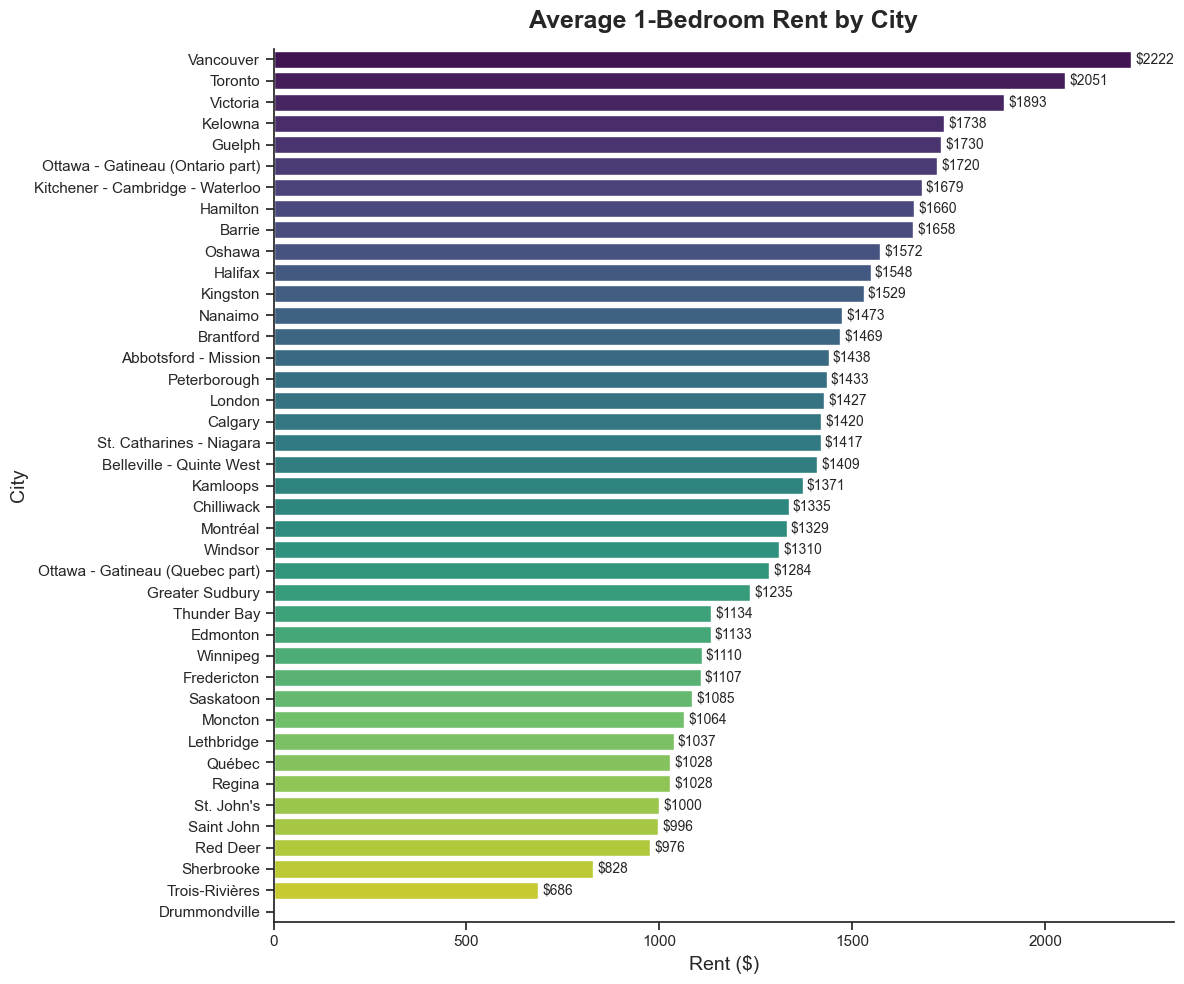

In [139]:
#import the libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Loading the dataset
df = pd.read_csv("Final_Cost_of_living_data.csv")
df.head()

#Average by rent by city
sns.set_theme(style="ticks")

# Sort cities by 1-bedroom rent
plot_df = Rental_pivot.groupby("City")["1_Bedroom_Rent"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 10))

ax = sns.barplot(
    data=plot_df,
    y="City",
    x="1_Bedroom_Rent",
    palette="viridis"
)

# Add rent labels to each bar
for i, row in plot_df.iterrows():
    if pd.notna(row["1_Bedroom_Rent"]):
        ax.text(
            row["1_Bedroom_Rent"] + 10,
            i,
            f"${int(row['1_Bedroom_Rent'])}",
            va='center',
            fontsize=10
        )

sns.despine(left=False, right=True, top=True, bottom=False)

plt.title("Average 1-Bedroom Rent by City", fontsize=18, weight="bold", pad=15)
plt.xlabel("Rent ($)", fontsize=14)
plt.ylabel("City", fontsize=14)

plt.tight_layout()
plt.show()

### 1.1 : Average Rent for 1 bedroom vs 2 bedroom by City

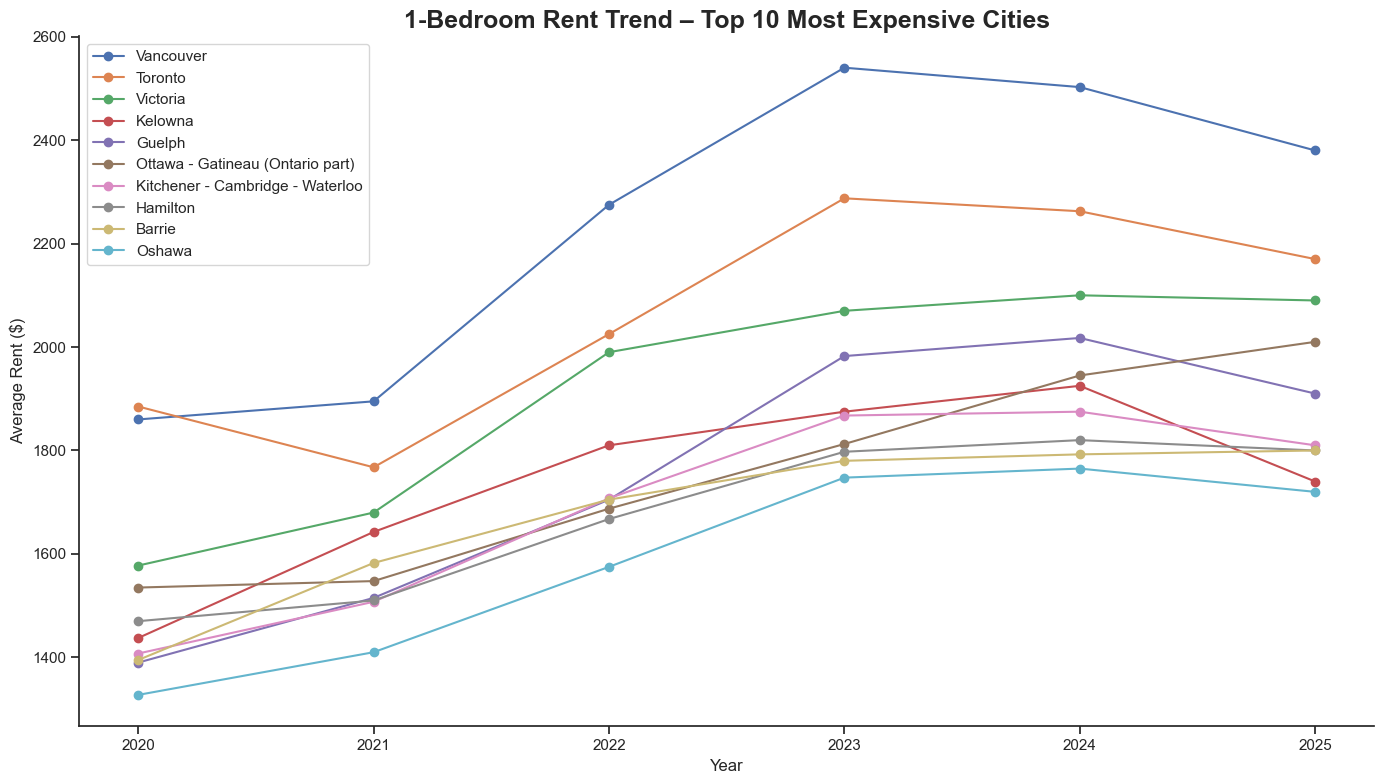

In [140]:
# Rent average by year
rent_yearly = merged.groupby("Year", as_index=False)[["1_Bedroom_Rent", "2_Bedroom_Rent"]].mean()
rent_yearly.head()

# Get top 10 most expensive cities by average 1-bedroom rent
top10 = (
    merged.groupby("City")["1_Bedroom_Rent"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

plt.figure(figsize=(14, 8))

for city in top10:
    temp = merged[merged["City"] == city].groupby("Year")["1_Bedroom_Rent"].mean()
    plt.plot(temp.index, temp.values, marker="o", label=city)

plt.title("1-Bedroom Rent Trend – Top 10 Most Expensive Cities", fontsize=18, weight="bold")
plt.xlabel("Year")
plt.ylabel("Average Rent ($)")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()




### 2.1: Rent trend over time (by year) in the top 10 cities with highest rent animation chart

In [141]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("Final_Cost_of_living_data.csv")

# Top 10 cities by average 1BR rent
top10 = (
    df.groupby("City")["1_Bedroom_Rent"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

trend = (
    df[df["City"].isin(top10)]
    .groupby(["City", "Year"], as_index=False)["1_Bedroom_Rent"]
    .mean()
)

import plotly.express as px

max_rent = trend["1_Bedroom_Rent"].max()

fig = px.bar(
    trend,
    x="1_Bedroom_Rent",
    y="City",
    color="City",
    animation_frame="Year",
    orientation="h",
    range_x=[0, max_rent * 1.2],
    labels={
        "1_Bedroom_Rent": "Average 1-Bedroom Rent ($)",
        "City": "City"
    },
    title="Trend of 1-Bedroom Rent – Top 10 Cities"
)

fig.update_layout(
    xaxis_title="Average 1-Bedroom Rent ($)",
    yaxis_title="City",
    title_font_size=22,
    legend_title_text="",
    template="plotly_white",
    height=700
)

fig.show()


### 3 : Consumer Price Index Over Time by Province

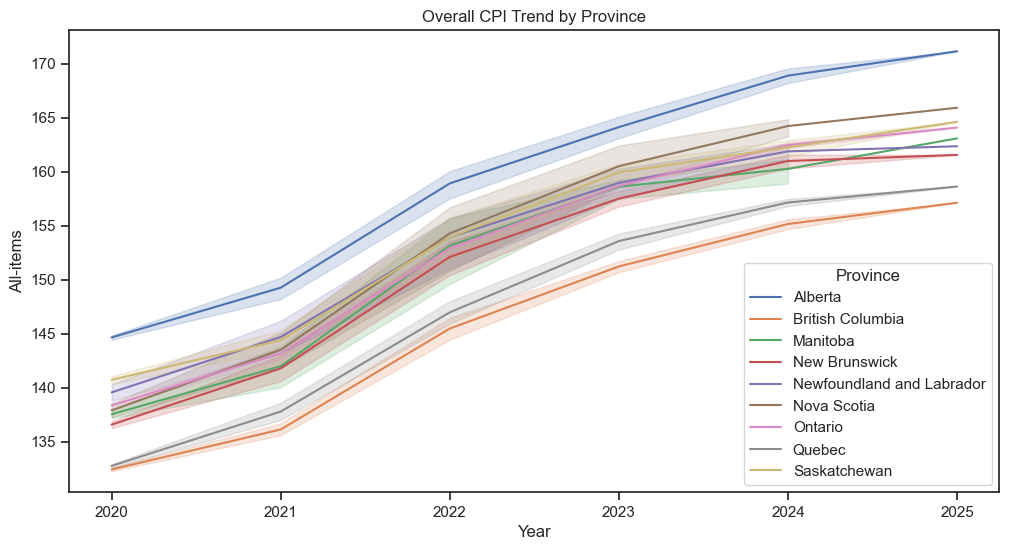

In [ ]:
# Overall CPI trend by Province
plt.figure(figsize=(12,6))
sns.lineplot(data=df,x="Year", y="All-items", hue="Province")
plt.title("Overall CPI Trend by Province")
loc = "upper right"
plt.show()

In [192]:
#provices with highest inflation

df.groupby("Province")["All-items"].mean().sort_values(ascending=False)


Province
Alberta                      157.846032
Saskatchewan                 152.846032
Nova Scotia                  152.753968
Newfoundland and Labrador    152.317460
Ontario                      151.741270
Manitoba                     150.925397
New Brunswick                150.361905
Quebec                       146.273016
British Columbia             144.709524
Name: All-items, dtype: float64

### 3.1 Year Over Year Inflation for Each Province
#### Calculation YoY Inflation per Povince

In [143]:
df = df.sort_values(["Province", "Year"])

df["YoY_inflation"] = (
    df.groupby("Province")["All-items"]
      .pct_change() * 100
)

df.head()

,Province,City,Year,Quarter,1_Bedroom_Rent,2_Bedroom_Rent,All-items,Food,Shelter,Energy,Gasoline,Goods,Services,Household_ops,Clothing and footwear,Transportation,Health and personal care,"Recreation, education and reading","Alcoholic beverages, tobacco products and recreational cannabis",YoY_inflation
84,Alberta,Calgary,2020,1,1180.0,1410.0,144.766667,153.200000,174.466667,160.700000,143.500000,123.566667,167.833333,122.566667,102.000000,146.133333,139.766667,114.633333,171.466667,NaN
85,Alberta,Calgary,2020,2,1190.0,1400.0,144.033333,153.700000,173.733333,148.666667,126.466667,121.566667,168.600000,122.633333,96.666667,144.700000,139.500000,114.666667,173.400000,-0.506562
86,Alberta,Calgary,2020,3,1190.0,1400.0,144.700000,152.800000,174.666667,164.466667,151.900000,122.933333,168.533333,122.666667,96.933333,147.233333,140.233333,115.466667,172.266667,0.462856
87,Alberta,Calgary,2020,4,1170.0,1380.0,145.133333,152.966667,175.533333,165.800000,152.300000,123.233333,169.100000,122.166667,97.533333,148.533333,140.233333,115.566667,171.133333,0.299470
147,Alberta,Edmonton,2020,1,1050.0,1290.0,144.766667,153.200000,174.466667,160.700000,143.500000,123.566667,167.833333,122.566667,102.000000,146.133333,139.766667,114.633333,171.466667,-0.252641


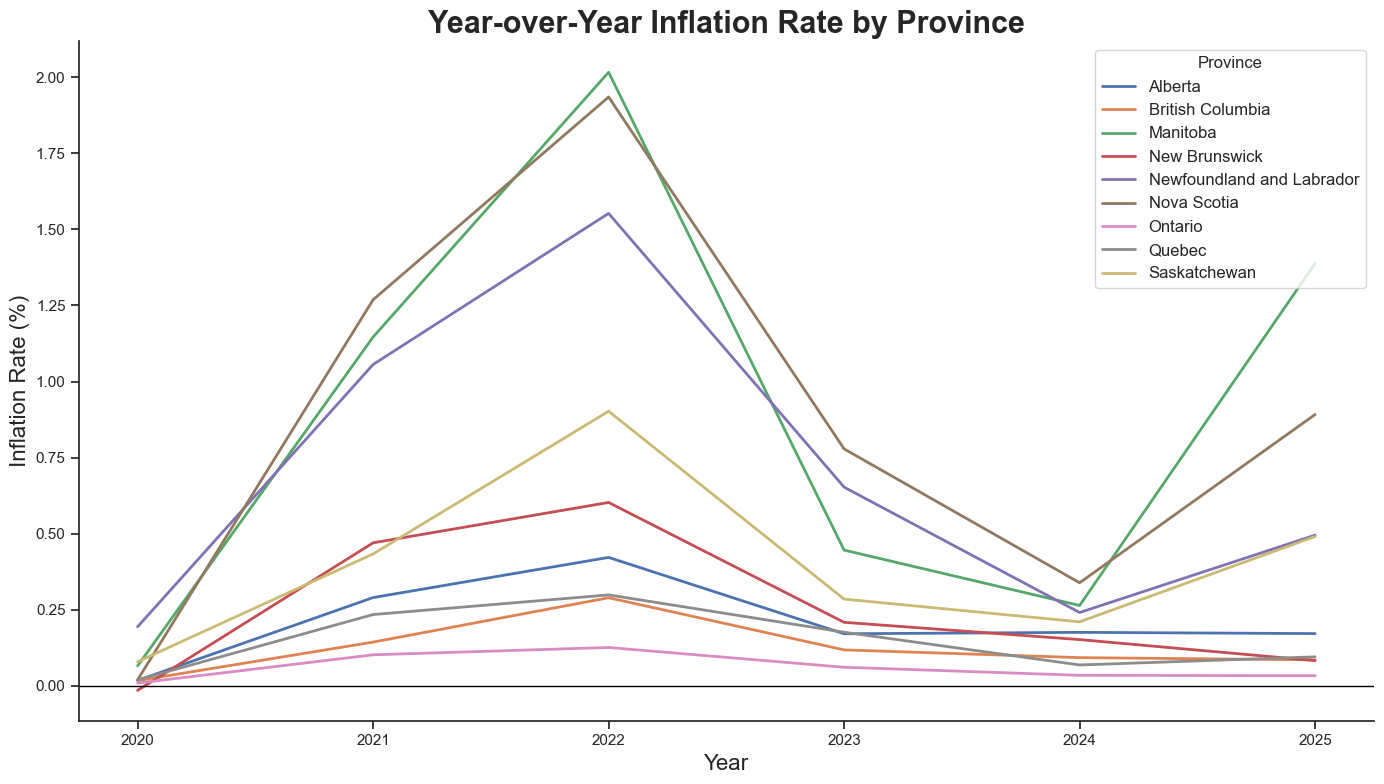

In [144]:
sns.set_theme(style="ticks")

plt.figure(figsize=(14, 8))

ax = sns.lineplot(
    data=df,
    x="Year",
    y="YoY_inflation",
    hue="Province",
    linewidth=2,
    errorbar=None
)

plt.title("Year-over-Year Inflation Rate by Province", fontsize=22, weight="bold")
plt.xlabel("Year", fontsize=16)
plt.ylabel("Inflation Rate (%)", fontsize=16)

plt.axhline(0, color="black", linewidth=1)

plt.legend(title="Province", fontsize=12, loc ="upper right")
sns.despine()

plt.tight_layout()
plt.show()


### 3.2 Inflation Year over Year for Common CPI components

In [145]:
df.columns


Index(['Province', 'City', 'Year', 'Quarter', '1_Bedroom_Rent',
       '2_Bedroom_Rent', 'All-items', 'Food', 'Shelter', 'Energy', 'Gasoline',
       'Goods', 'Services', 'Household_ops', 'Clothing and footwear',
       'Transportation', 'Health and personal care',
       'Recreation, education and reading',
       'Alcoholic beverages, tobacco products and recreational cannabis',
       'YoY_inflation'],
      dtype='object')

In [ ]:
components = ["Shelter", "Food", "Energy", "Gasoline", "Transportation",
              "Clothing and footwear", "Goods", "Services"]

for c in components:
    df[c + "_YoY"] = (
        df.groupby("Province")[c]
          .pct_change() * 100
    )
df.head()


,Province,City,Year,Quarter,1_Bedroom_Rent,2_Bedroom_Rent,All-items,Food,Shelter,Energy,...,"Alcoholic beverages, tobacco products and recreational cannabis",YoY_inflation,Shelter_YoY,Food_YoY,Energy_YoY,Gasoline_YoY,Transportation_YoY,Clothing and footwear_YoY,Goods_YoY,Services_YoY
84,Alberta,Calgary,2020,1,1180.0,1410.0,144.766667,153.200000,174.466667,160.700000,...,171.466667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
85,Alberta,Calgary,2020,2,1190.0,1400.0,144.033333,153.700000,173.733333,148.666667,...,173.400000,-0.506562,-0.420329,0.326371,-7.488073,-11.869919,-0.980839,-5.228758,-1.618559,0.456802
86,Alberta,Calgary,2020,3,1190.0,1400.0,144.700000,152.800000,174.666667,164.466667,...,172.266667,0.462856,0.537222,-0.585556,10.627803,20.110701,1.750749,0.275862,1.124212,-0.039541
87,Alberta,Calgary,2020,4,1170.0,1380.0,145.133333,152.966667,175.533333,165.800000,...,171.133333,0.299470,0.496183,0.109075,0.810701,0.263331,0.882952,0.618982,0.244035,0.336234
147,Alberta,Edmonton,2020,1,1050.0,1290.0,144.766667,153.200000,174.466667,160.700000,...,171.466667,-0.252641,-0.607672,0.152539,-3.075995,-5.778070,-1.615799,4.579631,0.270490,-0.749064


In [184]:
df_comp = (
    df_melted
    .groupby(["Province", "Year", "Component"], as_index=False)["Year_over_Year_inflation"]
    .mean()
)

# Clean the component names
df_melted["Component"] = df_melted["Component"].str.replace("_YoY", "")

df_melted.head()

,Province,Year,Component,Year_over_Year_inflation
0,Alberta,2020,Shelter,NaN
1,Alberta,2020,Shelter,-0.420329
2,Alberta,2020,Shelter,0.537222
3,Alberta,2020,Shelter,0.496183
4,Alberta,2020,Shelter,-0.607672


In [185]:
df_canada = (
    df_comp
    .groupby(["Year", "Component"], as_index=False)["Year_over_Year_inflation"]
    .mean()
)

df_canada["Component"] = df_canada["Component"].str.replace("_YoY", "")
df_canada.head()


,Year,Component,Year_over_Year_inflation
0,2020,Clothing and footwear,-0.405810
1,2020,Energy,-0.066486
2,2020,Food,0.049759
3,2020,Gasoline,0.484781
4,2020,Goods,-0.009097


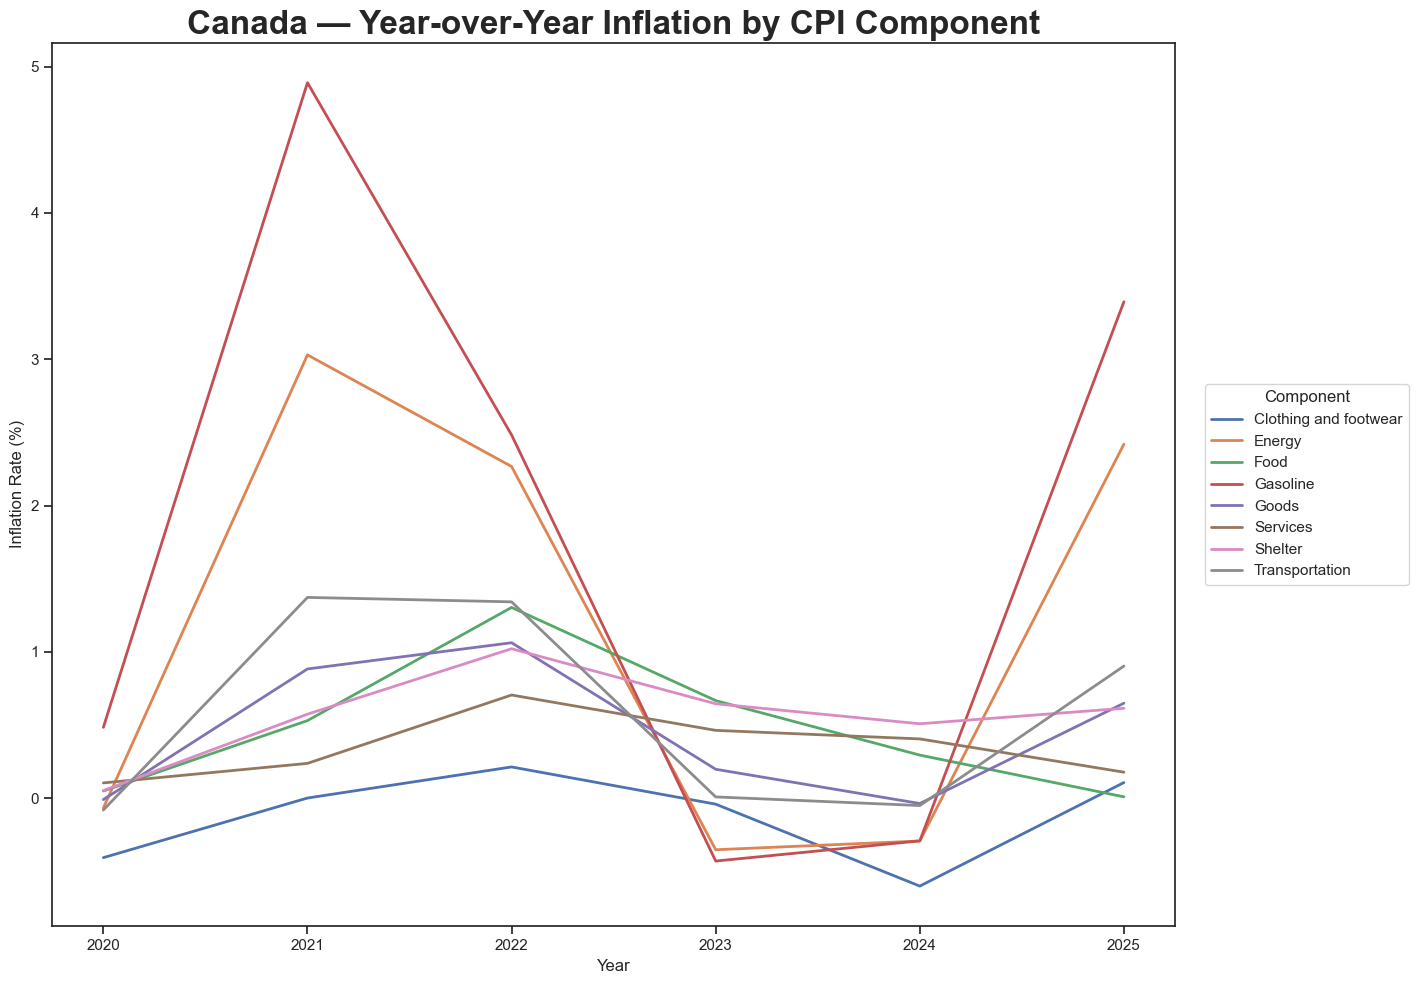

In [186]:
# plotting CPI component canada wide over time

plt.figure(figsize=(18, 10))

sns.lineplot(
    data=df_canada,
    x="Year",
    y="Year_over_Year_inflation",
    hue="Component",
    linewidth=2,
    errorbar=None
)
df_canada["Component"] = df_canada["Component"].str.replace("_YoY", "")

plt.title("Canada — Year-over-Year Inflation by CPI Component", fontsize=24, weight="bold")
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")

plt.legend(title="Component", loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()


## Advanced Analysis
### Correlation Analysis

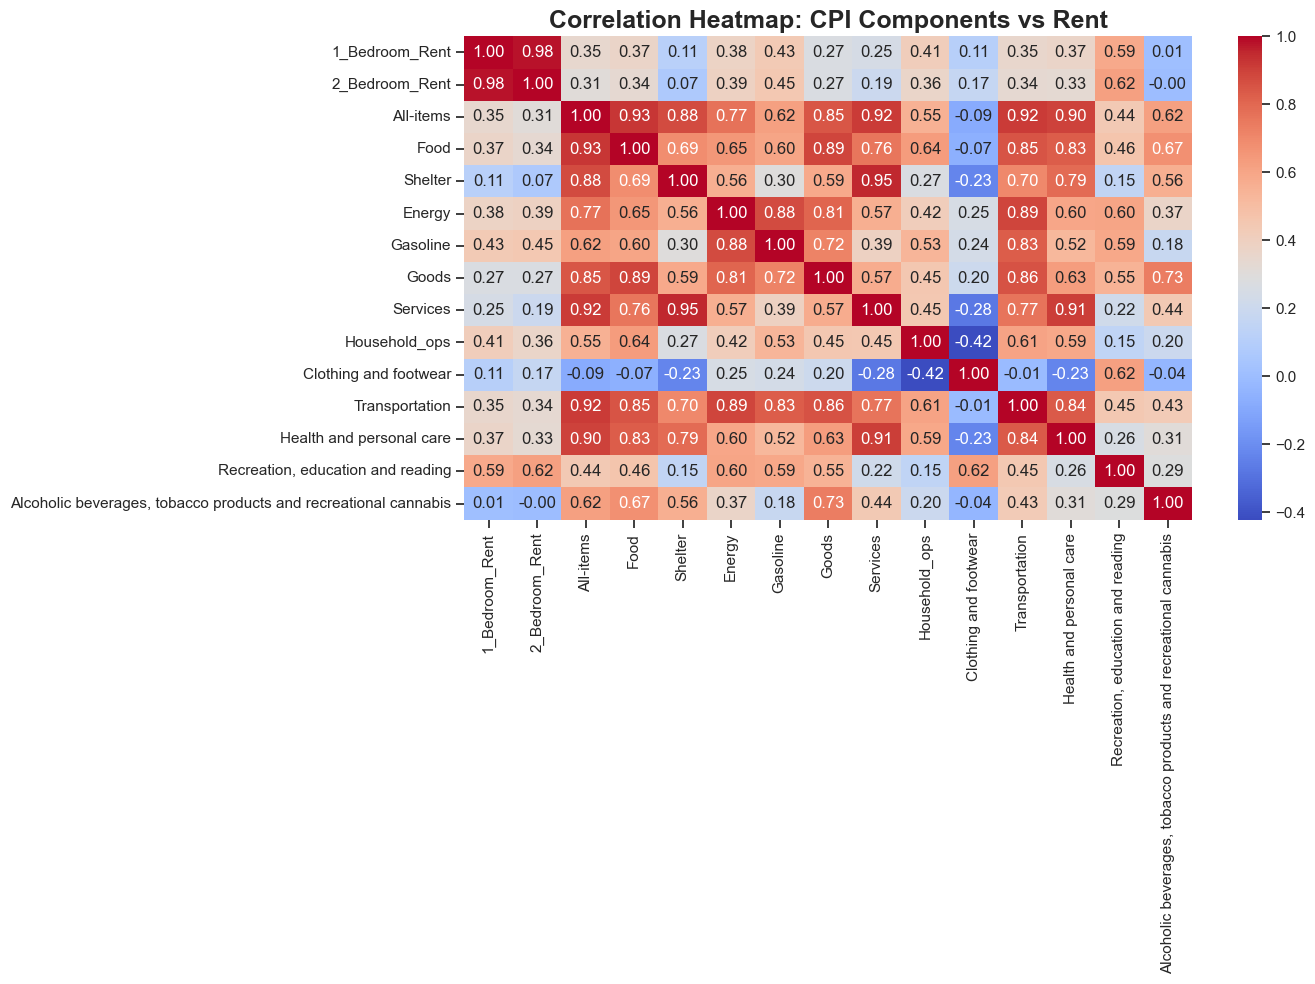

In [210]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    "1_Bedroom_Rent",
    "2_Bedroom_Rent",
    "All-items",
    "Food",
    "Shelter",
    "Energy",
    "Gasoline",
    "Goods",
    "Services",
    "Household_ops",
    "Clothing and footwear",
    "Transportation",
    "Health and personal care",
    "Recreation, education and reading",
    "Alcoholic beverages, tobacco products and recreational cannabis"
]

# Filter only columns that actually exist in df
corr_cols = [c for c in corr_cols if c in df.columns]

df_corr = df[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: CPI Components vs Rent", fontsize=18, weight="bold")
plt.tight_layout()
plt.show()


#### Which component drive the rent increase most

In [212]:
cpi_components = [
    c for c in corr_cols if c not in ["1_Bedroom_Rent", "2_Bedroom_Rent"]
]

rent_corr = df_corr["2_Bedroom_Rent"].loc[cpi_components]



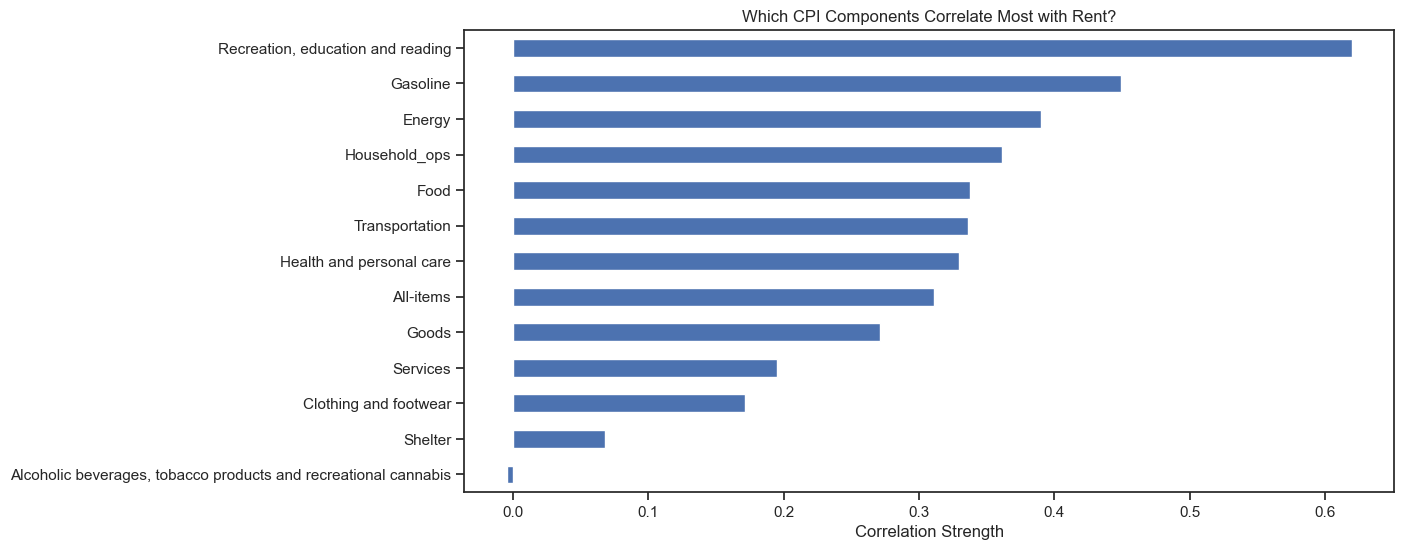

In [213]:
rent_corr.sort_values().plot(kind="barh", figsize=(12, 6))
plt.title("Which CPI Components Correlate Most with Rent?")
plt.xlabel("Correlation Strength")
plt.show()

